# Bài thực hành: Image Filtering với các Kernel phổ biến

Notebook này dùng ảnh xám để thực hành các phép lọc ảnh dựa trên **filter/kernel**. Mục tiêu là hiểu cách kernel tác động lên từng pixel, cách xử lý biên bằng padding, và sự khác nhau giữa các bộ lọc tuyến tính và phi tuyến.

## Nội dung chính

1. **Gaussian filter**: tạo Gaussian kernel thủ công, tự cài đặt phép lọc, rồi so sánh với OpenCV.
2. **Mean filter**: dùng kernel trung bình để làm mờ ảnh và so sánh với Gaussian.
3. **Median filter**: lọc phi tuyến, đặc biệt phù hợp với nhiễu salt-and-pepper.
4. **Bilateral filter**: làm mượt ảnh nhưng hạn chế làm mờ biên bằng cách kết hợp khoảng cách không gian và độ giống intensity.

## Filter và kernel là gì?

Trong xử lý ảnh, **filter** là phép biến đổi tạo ảnh mới từ ảnh gốc. Filter có thể dùng để làm mờ ảnh, giảm nhiễu, làm sắc nét, phát hiện cạnh, hoặc làm mượt vùng đồng nhất trong khi vẫn cố gắng giữ biên.

Nhiều filter được biểu diễn bằng một ma trận nhỏ gọi là **kernel**, **mask**, hoặc **spatial mask**. Ví dụ kernel `3 x 3`:

```text
w11  w12  w13
w21  w22  w23
w31  w32  w33
```

Khi áp dụng kernel lên ảnh, ta đặt kernel lên vùng lân cận của một pixel, nhân từng pixel trong vùng đó với trọng số tương ứng, rồi cộng lại để tạo pixel mới:

```text
output = sum(image_patch * kernel)
```

## Correlation và convolution

Cả **correlation** và **convolution** đều trượt kernel qua ảnh và tính tổng nhân từng phần tử. Điểm khác nhau nằm ở chiều của kernel.

| Phép toán | Cách áp dụng kernel | Ghi chú |
|---|---|---|
| Correlation | Dùng kernel đúng chiều ban đầu | Thường được hiểu như so khớp mẫu |
| Convolution | Lật kernel `180°` trước khi áp dụng | Định nghĩa toán học trong xử lý tín hiệu |

Với kernel đối xứng như **Mean** hoặc **Gaussian**, convolution và correlation cho kết quả giống nhau. Với kernel không đối xứng, ví dụ Sobel theo một hướng, kết quả có thể bị đổi dấu hoặc đổi hướng.

## Padding trong filtering

Khi kernel trượt đến biên ảnh, một phần kernel sẽ nằm ngoài ảnh. Ta dùng **padding** để thêm viền giả xung quanh ảnh.

| Loại padding | Ví dụ 1D với `[10, 20, 30, 40]` | Đặc điểm |
|---|---|---|
| Zero | `[0, 10, 20, 30, 40, 0]` | Đơn giản nhưng có thể tạo viền tối |
| Reflect | `[20, 10, 20, 30, 40, 30]` | Biên tự nhiên hơn, thường dùng trong xử lý ảnh |
| Replicate | `[10, 10, 20, 30, 40, 40]` | Giữ giá trị biên ổn định nhưng có thể làm vùng biên phẳng |

Với kernel size `k`, số pixel padding thường là:

```text
pad = k // 2
```

Ví dụ: kernel `3 x 3` có `pad = 1`, kernel `5 x 5` có `pad = 2`, kernel `7 x 7` có `pad = 3`.

## Tóm tắt các filter trong notebook

| Filter | Loại | Cách tính | Ưu điểm | Nhược điểm |
|---|---|---|---|---|
| Mean | Linear | Trung bình đều trong vùng lân cận | Đơn giản, nhanh | Dễ làm mờ cạnh |
| Gaussian | Linear | Trung bình có trọng số theo khoảng cách | Mờ tự nhiên hơn Mean | Vẫn làm mờ cạnh |
| Median | Nonlinear | Lấy trung vị trong vùng lân cận | Tốt với salt-and-pepper noise | Có thể làm mất chi tiết nhỏ |
| Bilateral | Nonlinear | Kết hợp khoảng cách không gian và độ giống intensity | Làm mượt nhưng giữ cạnh tốt hơn | Chậm hơn, nhiều tham số hơn |


## 0. Chuẩn bị môi trường và ảnh đầu vào

Phần này import thư viện, đọc ảnh Lena ở dạng grayscale, rồi cắt một vùng nhỏ để các bộ lọc thủ công chạy nhanh và dễ quan sát hơn.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


(512, 512)
uint8
(100, 100)


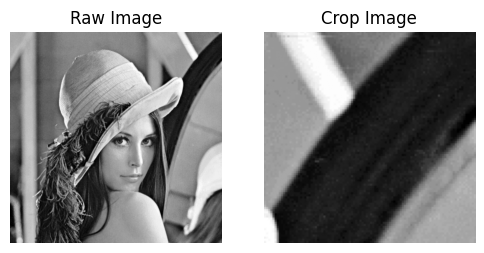

In [2]:
img_path = "dataset/Lena.png"
img_raw = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

assert img_raw is not None, f"Cannot read image at: {img_path}"

x = 30; y = 412; w = 100
img_crop = img_raw[x:x+w, y:y+w]
img = img_crop  # Compatibility alias for the existing Gaussian padding demo.

print(img_raw.shape)
print(img_raw.dtype)

print(img_crop.shape)

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(img_raw, cmap="gray")
plt.title("Raw Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_crop, cmap="gray")
plt.title("Crop Image")
plt.axis("off")

plt.show()


## 1. Gaussian Filter

Phần Gaussian đã được giữ nguyên theo notebook ban đầu: tạo Gaussian kernel thủ công, áp dụng lên ảnh crop bằng hàm convolution tự viết, rồi so sánh với `cv2.GaussianBlur`.

Gaussian filter dùng trọng số lớn ở gần tâm kernel và trọng số nhỏ dần khi đi xa tâm. Công thức Gaussian 2D:

$$
G_\sigma(x, y) = \frac{1}{2\pi\sigma^2}\exp\left(-\frac{x^2 + y^2}{2\sigma^2}\right)
$$

Với kernel size `k`, bán kính kernel là:

$$
r = \left\lfloor \frac{k}{2} \right\rfloor
$$

Sau khi tính các trọng số Gaussian, kernel được chuẩn hóa để tổng trọng số bằng `1`:

$$
\hat{G}(i, j) = \frac{G_\sigma(i, j)}{\sum_{u=-r}^{r}\sum_{v=-r}^{r}G_\sigma(u, v)}
$$

Pixel đầu ra được tính bằng tổng có trọng số trên vùng lân cận:

$$
I_{out}(x, y) = \sum_{i=-r}^{r}\sum_{j=-r}^{r}\hat{G}(i, j)I(x+i, y+j)
$$

Vì Gaussian kernel đối xứng, correlation và convolution cho cùng kết quả trong trường hợp này.


In [3]:
# manually implement Gaussian Filter

kernel_size = 7 # odd nums (3,5,7,...)
sigma = 1000.0 # float

assert kernel_size % 2 == 1, "Kernal-Size must be an odd number"

Kernel 7x7, with sigma = 1000.0 is: 
 [[0.02040806 0.02040811 0.02040814 0.02040815 0.02040814 0.02040811
  0.02040806]
 [0.02040811 0.02040816 0.02040819 0.0204082  0.02040819 0.02040816
  0.02040811]
 [0.02040814 0.02040819 0.02040822 0.02040823 0.02040822 0.02040819
  0.02040814]
 [0.02040815 0.0204082  0.02040823 0.02040824 0.02040823 0.0204082
  0.02040815]
 [0.02040814 0.02040819 0.02040822 0.02040823 0.02040822 0.02040819
  0.02040814]
 [0.02040811 0.02040816 0.02040819 0.0204082  0.02040819 0.02040816
  0.02040811]
 [0.02040806 0.02040811 0.02040814 0.02040815 0.02040814 0.02040811
  0.02040806]]


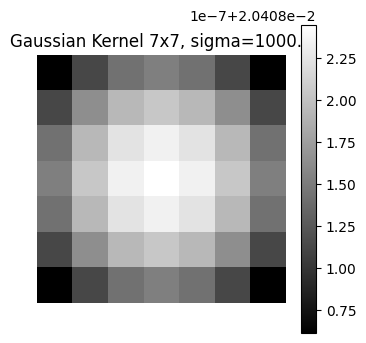

In [4]:
# create Gaussian function

def gaussian_filter(kernel_size, sigma):
    radius = kernel_size // 2
    kernel = np.zeros((kernel_size, kernel_size), dtype=np.float64)

    for y in range(-radius, radius+1):
        for x in range(-radius, radius+1):
            value = (1/(2 * np.pi * sigma**2)) * np.exp(-((x**2 + y**2)/(2*sigma**2)))
            kernel[y+radius, x+radius] = value

    kernel = kernel / np.sum(kernel)
            
    return kernel

gaussian_kernel = gaussian_filter(kernel_size, sigma)

print(f"Kernel {kernel_size}x{kernel_size}, with sigma = {sigma} is: \n {gaussian_kernel}")

plt.figure(figsize=(4, 4))
plt.imshow(gaussian_kernel, cmap="gray")
plt.title(f"Gaussian Kernel {kernel_size}x{kernel_size}, sigma={sigma}")
plt.colorbar()
plt.axis("off")
plt.show()

### 1.1 Padding và convolution thủ công

Các cell bên dưới dùng reflect padding rồi trượt kernel qua từng pixel để tính ảnh kết quả.


In [5]:
# Padding:

pad = kernel_size // 2 # Same like radius

padded_img = np.pad(img, pad_width=pad, mode="reflect")

# Mode: zero, reflect, replicate

print(f"Origin Image Shape: {img.shape}")
print(f"Padded Image Shape: {padded_img.shape}")

Origin Image Shape: (100, 100)
Padded Image Shape: (106, 106)


In [6]:
# Implement Convolution Function

def manual_convolution(raw_img, gau_filter):
    kernel_size = gau_filter.shape[0]
    pad = kernel_size //  2

    hei, wid = raw_img.shape

    output = np.zeros_like(raw_img, dtype=np.float64)

    # Implement Padding:
    padded = np.pad(raw_img, pad_width=pad, mode="reflect")

    for row in range(hei):
        for col in range(wid):
            patch = padded[row:row + kernel_size, col:col + kernel_size]

            new_pixel = np.sum(patch * gau_filter)

            output[row, col] = new_pixel

    output = np.clip(output, 0, 255) # Compress into range (0, 255)
    output = output.astype(np.uint8) # Compress into dtype uinit8

    return output

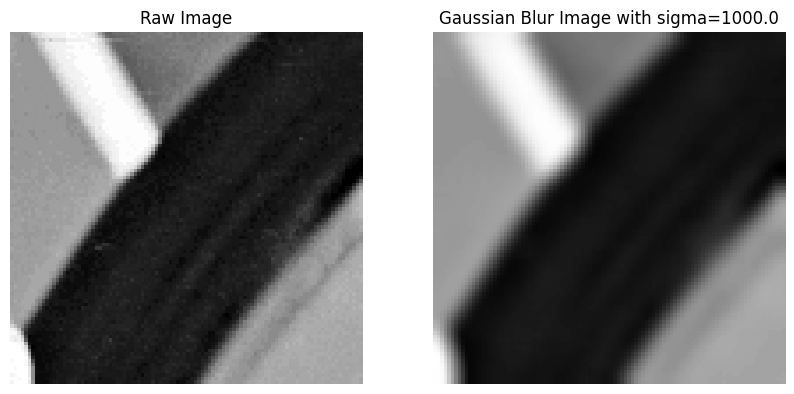

In [7]:
manual_gaussian = manual_convolution(img_crop, gaussian_kernel)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_crop, cmap="gray")
plt.title("Raw Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(manual_gaussian, cmap="gray")
plt.title(f"Gaussian Blur Image with sigma={sigma}")
plt.axis("off")

plt.show()

### 1.2 Gaussian bằng OpenCV

So sánh kết quả tự cài đặt với `cv2.GaussianBlur` để kiểm tra sai khác trung bình và sai khác lớn nhất.


In [8]:
opencv_gaussian = cv2.GaussianBlur(
    img_crop,
    ksize=(kernel_size, kernel_size),
    sigmaX=sigma
)

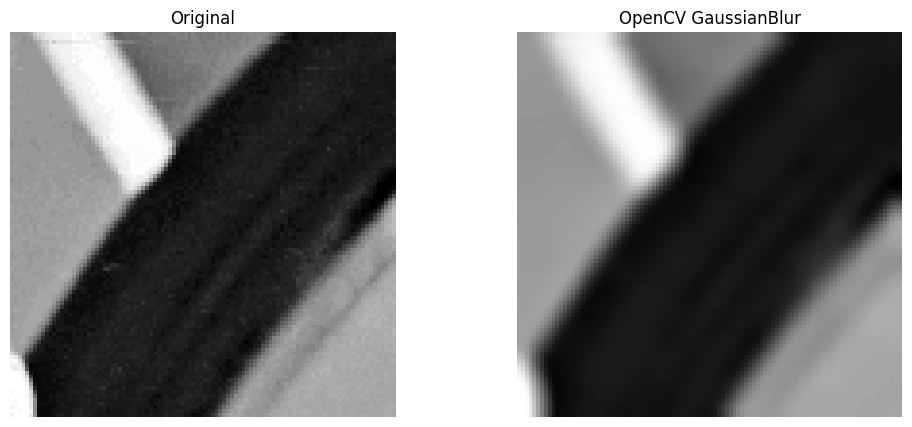

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_crop, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(opencv_gaussian, cmap="gray")
plt.title("OpenCV GaussianBlur")
plt.axis("off")

plt.show()

In [10]:
diff = cv2.absdiff(manual_gaussian, opencv_gaussian)

print("Mean difference:", diff.mean())
print("Max difference:", diff.max())

Mean difference: 0.496
Max difference: 1


## 2. Mean Filter / Box Blur

Mean filter dùng kernel có các trọng số bằng nhau. Mỗi pixel mới là trung bình cộng của các pixel trong vùng lân cận.

Với kernel `k x k`:

```text
kernel = ones(k, k) / (k * k)
```


In [11]:
# Manual Mean Filter

mean_kernel_size = 5
mean_kernel = np.ones((mean_kernel_size, mean_kernel_size), dtype=np.float64)
mean_kernel = mean_kernel / mean_kernel.sum()

manual_mean = manual_convolution(img_crop, mean_kernel)
opencv_mean = cv2.blur(img_crop, ksize=(mean_kernel_size, mean_kernel_size))

mean_diff = cv2.absdiff(manual_mean, opencv_mean)

print(f"Mean kernel {mean_kernel_size}x{mean_kernel_size}:")
print(mean_kernel)
print("Mean difference:", mean_diff.mean())
print("Max difference:", mean_diff.max())


Mean kernel 5x5:
[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]
Mean difference: 0.4785
Max difference: 1


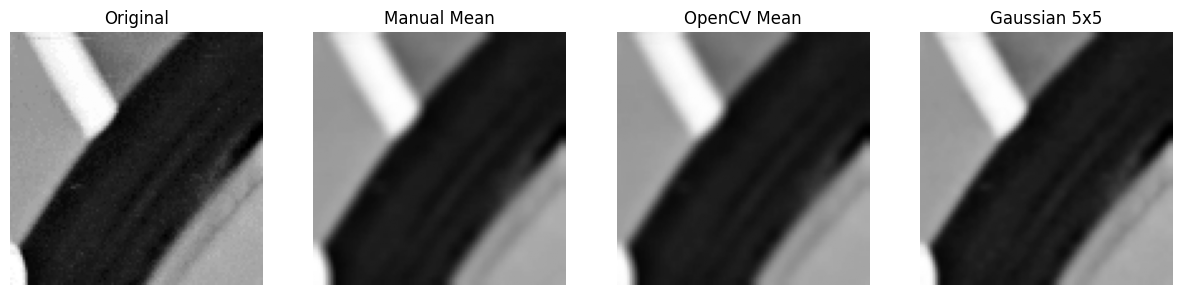

In [12]:
# Compare Mean and Gaussian smoothing

mean_gaussian_reference = cv2.GaussianBlur(
    img_crop,
    ksize=(mean_kernel_size, mean_kernel_size),
    sigmaX=1.0
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_crop, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(manual_mean, cmap="gray")
plt.title("Manual Mean")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(opencv_mean, cmap="gray")
plt.title("OpenCV Mean")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(mean_gaussian_reference, cmap="gray")
plt.title("Gaussian 5x5")
plt.axis("off")

plt.show()


## 3. Median Filter

Median filter là bộ lọc phi tuyến. Thay vì nhân kernel rồi cộng, filter lấy giá trị trung vị trong vùng lân cận.

Median filter thường xử lý tốt **salt-and-pepper noise**, vì các điểm nhiễu rất sáng hoặc rất tối thường là giá trị cực đoan và không nằm ở trung vị.


In [13]:
# Add salt-and-pepper noise to make Median filter behavior easier to see.

def add_salt_pepper_noise(raw_img, amount=0.08, salt_vs_pepper=0.5, seed=42):
    noisy = raw_img.copy()
    rng = np.random.default_rng(seed)

    num_noisy_pixels = int(amount * raw_img.size)
    noisy_indices = rng.choice(raw_img.size, size=num_noisy_pixels, replace=False)
    num_salt = int(num_noisy_pixels * salt_vs_pepper)

    flat = noisy.reshape(-1)
    flat[noisy_indices[:num_salt]] = 255
    flat[noisy_indices[num_salt:]] = 0

    return noisy


def manual_median_filter(raw_img, kernel_size):
    assert kernel_size % 2 == 1, "Kernel size must be odd"

    pad = kernel_size // 2
    hei, wid = raw_img.shape
    padded = np.pad(raw_img, pad_width=pad, mode="reflect")
    output = np.zeros_like(raw_img, dtype=np.uint8)

    for row in range(hei):
        for col in range(wid):
            patch = padded[row:row + kernel_size, col:col + kernel_size]
            output[row, col] = np.median(patch)

    return output


median_kernel_size = 5
noisy_img = add_salt_pepper_noise(img_crop, amount=0.08)
manual_median = manual_median_filter(noisy_img, median_kernel_size)
opencv_median = cv2.medianBlur(noisy_img, ksize=median_kernel_size)

median_diff = cv2.absdiff(manual_median, opencv_median)

print("Mean difference:", median_diff.mean())
print("Max difference:", median_diff.max())


Mean difference: 0.0723
Max difference: 31


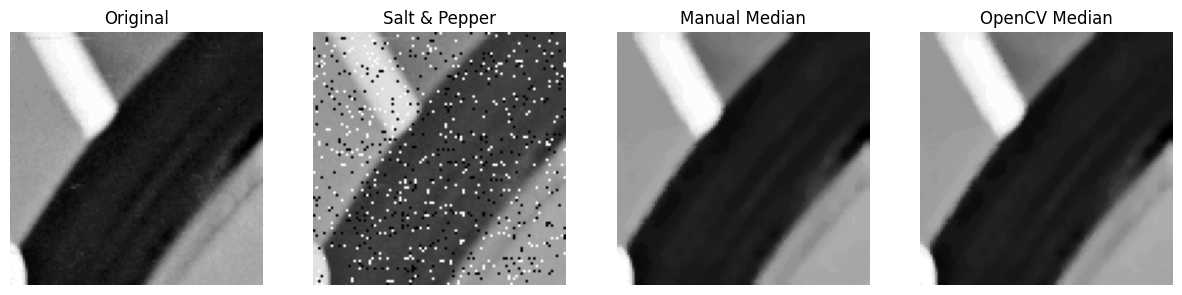

In [14]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_crop, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(noisy_img, cmap="gray")
plt.title("Salt & Pepper")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(manual_median, cmap="gray")
plt.title("Manual Median")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(opencv_median, cmap="gray")
plt.title("OpenCV Median")
plt.axis("off")

plt.show()


## 4. Bilateral Filter

Bilateral filter làm mượt ảnh giống Gaussian, nhưng thêm một trọng số theo độ giống intensity để hạn chế trộn pixel qua biên.

Trọng số cuối cùng là tích của hai thành phần:

```text
final_weight = spatial_weight * range_weight
```

- `spatial_weight`: pixel càng gần tâm thì trọng số càng lớn.
- `range_weight`: pixel càng giống intensity của pixel trung tâm thì trọng số càng lớn.

Gọi `p` là vị trí pixel trung tâm và `q` là vị trí pixel lân cận trong cửa sổ lọc `Omega`. Trọng số không gian:

$$
G_s(p, q) = \exp\left(-\frac{\lVert p-q \rVert^2}{2\sigma_s^2}\right)
$$

Trọng số intensity/range:

$$
G_r(I_p, I_q) = \exp\left(-\frac{\lVert I_p-I_q \rVert^2}{2\sigma_r^2}\right)
$$

Trọng số kết hợp:

$$
w(p, q) = G_s(p, q)G_r(I_p, I_q)
$$

Hệ số chuẩn hóa:

$$
W_p = \sum_{q \in \Omega} w(p, q)
$$

Công thức Bilateral filter:

$$
BF[I]_p = \frac{1}{W_p}\sum_{q \in \Omega} I_q w(p, q)
$$

`sigma_s` điều khiển mức ảnh hưởng theo khoảng cách không gian, còn `sigma_r` điều khiển mức cho phép khác biệt intensity.


In [15]:
# Manual Bilateral Filter


def manual_bilateral_filter(raw_img, kernel_size, sigma_space, sigma_range):
    assert kernel_size % 2 == 1, "Kernel size must be odd"

    pad = kernel_size // 2
    hei, wid = raw_img.shape
    raw_float = raw_img.astype(np.float64)
    padded = np.pad(raw_float, pad_width=pad, mode="reflect")
    output = np.zeros_like(raw_float)

    coords = np.arange(-pad, pad + 1)
    xx, yy = np.meshgrid(coords, coords)
    spatial_weight = np.exp(-(xx**2 + yy**2) / (2 * sigma_space**2))

    for row in range(hei):
        for col in range(wid):
            patch = padded[row:row + kernel_size, col:col + kernel_size]
            center_value = padded[row + pad, col + pad]

            range_weight = np.exp(-((patch - center_value) ** 2) / (2 * sigma_range**2))
            weights = spatial_weight * range_weight

            output[row, col] = np.sum(weights * patch) / np.sum(weights)

    output = np.clip(output, 0, 255)
    return output.astype(np.uint8)


bilateral_kernel_size = 7
sigma_space = 3.0
sigma_range = 30.0

manual_bilateral = manual_bilateral_filter(
    img_crop,
    kernel_size=bilateral_kernel_size,
    sigma_space=sigma_space,
    sigma_range=sigma_range
)

opencv_bilateral = cv2.bilateralFilter(
    img_crop,
    d=bilateral_kernel_size,
    sigmaColor=sigma_range,
    sigmaSpace=sigma_space,
    borderType=cv2.BORDER_REFLECT
)

bilateral_diff = cv2.absdiff(manual_bilateral, opencv_bilateral)

print("Mean difference:", bilateral_diff.mean())
print("Max difference:", bilateral_diff.max())


Mean difference: 0.6658
Max difference: 7


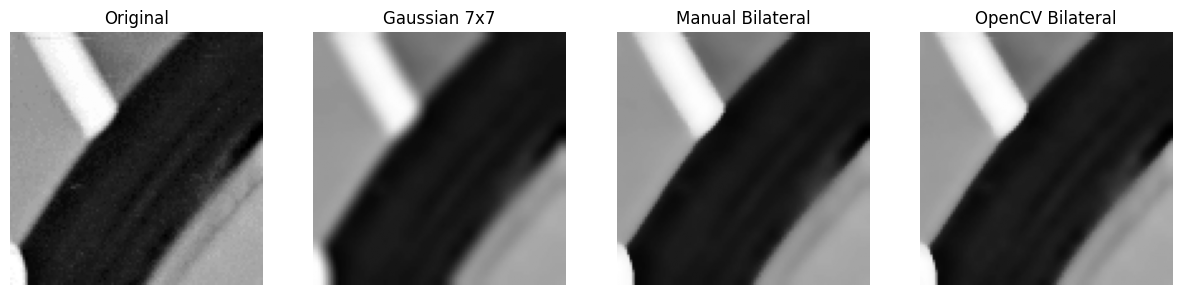

In [16]:
# Compare edge-preserving smoothing against Gaussian smoothing.

bilateral_gaussian_reference = cv2.GaussianBlur(
    img_crop,
    ksize=(bilateral_kernel_size, bilateral_kernel_size),
    sigmaX=sigma_space
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_crop, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(bilateral_gaussian_reference, cmap="gray")
plt.title("Gaussian 7x7")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(manual_bilateral, cmap="gray")
plt.title("Manual Bilateral")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(opencv_bilateral, cmap="gray")
plt.title("OpenCV Bilateral")
plt.axis("off")

plt.show()


## 5. Tổng hợp so sánh

Cell cuối đặt các kết quả chính cạnh nhau để dễ quan sát: Mean và Gaussian làm mờ tổng thể, Median xử lý nhiễu salt-and-pepper, còn Bilateral làm mượt nhưng giữ biên tốt hơn Gaussian trong nhiều trường hợp.


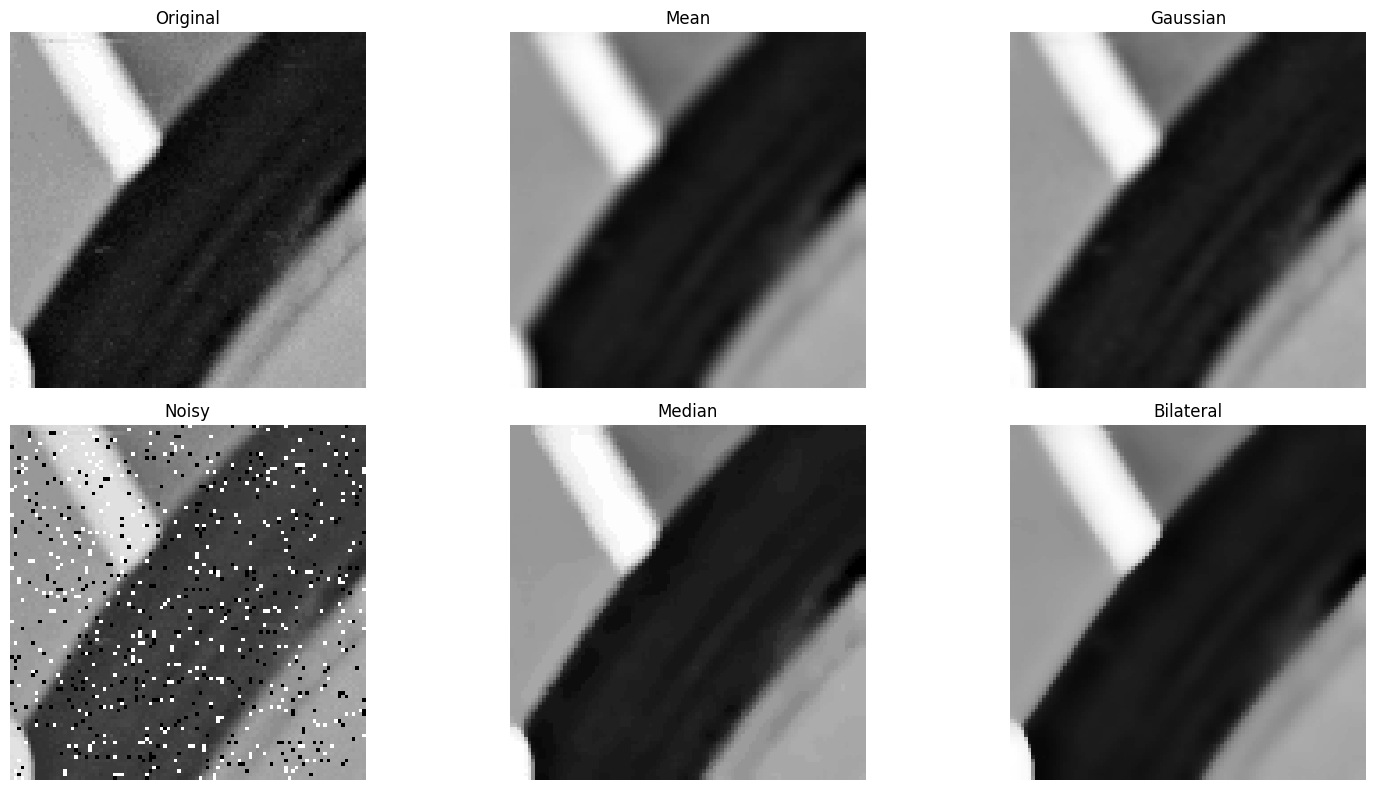

In [17]:
plt.figure(figsize=(16, 8))

images = [
    (img_crop, "Original"),
    (manual_mean, "Mean"),
    (mean_gaussian_reference, "Gaussian"),
    (noisy_img, "Noisy"),
    (manual_median, "Median"),
    (manual_bilateral, "Bilateral"),
]

for idx, (image, title) in enumerate(images, start=1):
    plt.subplot(2, 3, idx)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()


## 6. Kết luận ngắn

- **Mean**: đơn giản và nhanh, nhưng làm mờ cạnh rõ rệt.
- **Gaussian**: làm mờ tự nhiên hơn Mean vì trọng số tập trung quanh tâm.
- **Median**: phù hợp với nhiễu salt-and-pepper vì dùng trung vị thay vì trung bình.
- **Bilateral**: cân bằng giữa làm mượt và giữ biên bằng cách xét cả khoảng cách không gian lẫn độ giống intensity.
